# 01 EDA: Trader Performance vs Bitcoin Sentiment

Cleaned exploratory data analysis on the joined Hyperliquid trades + Bitcoin Fear & Greed Index dataset. The headline regime and trader-ranking results from this notebook feed the v1 report. v2 builds the ML modelling and backtest on top in the next two notebooks.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_trades, load_sentiment
from src.features import attach_sentiment, add_trade_features, REGIME_ORDER
from src.metrics import all_metrics, metrics_by_group

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)

FIG_DIR = Path('../outputs/figures') if Path.cwd().name == 'notebooks' else Path('outputs/figures')
TBL_DIR = Path('../outputs/tables') if Path.cwd().name == 'notebooks' else Path('outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {'Extreme Fear':'#7a0d0d','Fear':'#d0473a','Neutral':'#9a9a9a','Greed':'#3aa05a','Extreme Greed':'#117a3a'}
print('imports ok')


imports ok


## Load and join

In [2]:
trades = load_trades()
sent = load_sentiment()
df = attach_sentiment(trades, sent)
df = add_trade_features(df)
print('shape:', df.shape)
print('regime nulls:', df['regime'].isna().sum())
df[['account','coin','date','closed_pnl','size_usd','side','regime','fg_value']].head(3)


shape: (211224, 30)
regime nulls: 6


,account,coin,date,closed_pnl,size_usd,side,regime,fg_value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,7872.16,BUY,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,127.68,BUY,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,1150.63,BUY,Extreme Greed,80.0


## Regime-level metrics

In [3]:
regime_table = metrics_by_group(df.dropna(subset=['regime']), 'regime')
regime_table = regime_table.set_index('regime').reindex(REGIME_ORDER).reset_index()
regime_table.to_csv(TBL_DIR / 'metrics_by_regime.csv', index=False)
regime_table.round(4)


,regime,trades,pnl_total,pnl_mean,pnl_median,win_rate,profit_factor,sharpe,max_drawdown,trading_frequency,roi,risk_std
0,Extreme Fear,21400,7.391102e+05,34.5379,0.0,0.7622,2.1615,9.9605,-86890.7563,1528.5714,0.0065,1136.0561
1,Fear,61837,3.357155e+06,54.2904,0.0,0.8729,6.6556,7.2953,-135685.6661,679.5275,0.0069,935.3554
2,Neutral,37686,1.292921e+06,34.3077,0.0,0.8239,4.3213,9.7032,-10116.8756,562.4776,0.0072,517.1222
3,Greed,50303,2.150129e+06,42.7436,0.0,0.7689,3.0309,3.4094,-419020.2257,260.6373,0.0075,1116.0284
4,Extreme Greed,39992,2.715171e+06,67.8929,0.0,0.8917,11.0228,6.2481,-137369.6087,350.8070,0.0218,766.8283


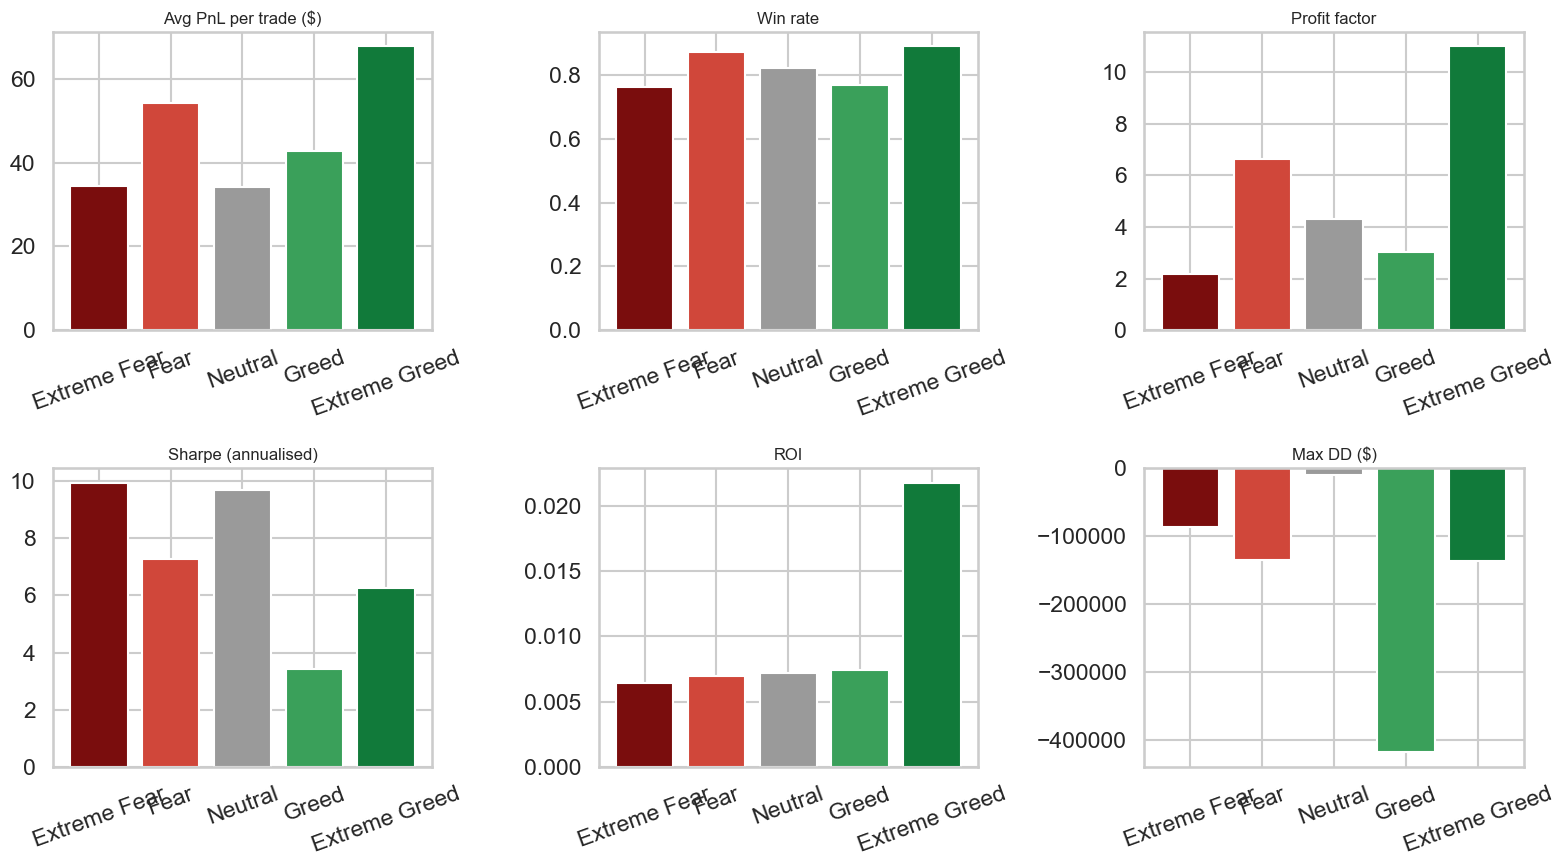

In [4]:
metrics_to_plot = ['pnl_mean','win_rate','profit_factor','sharpe','roi','max_drawdown']
titles = {'pnl_mean':'Avg PnL per trade ($)','win_rate':'Win rate','profit_factor':'Profit factor',
          'sharpe':'Sharpe (annualised)','roi':'ROI','max_drawdown':'Max DD ($)'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flat, metrics_to_plot):
    vals = regime_table.set_index('regime')[m].reindex(REGIME_ORDER)
    ax.bar(vals.index, vals.values, color=[PALETTE[r] for r in vals.index])
    ax.set_title(titles[m], fontsize=12)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_by_regime.png', dpi=140)
plt.show()
plt.close('all')


## Sentiment timeline

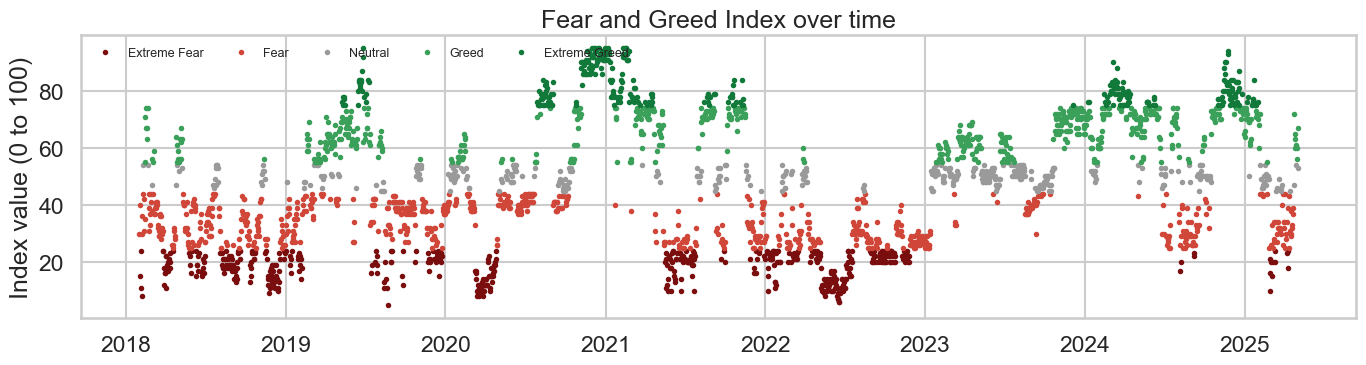

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
for r, color in PALETTE.items():
    mask = sent['regime'] == r
    ax.scatter(sent.loc[mask,'date'], sent.loc[mask,'fg_value'], s=6, color=color, label=r)
ax.set_title('Fear and Greed Index over time')
ax.set_ylabel('Index value (0 to 100)')
ax.legend(loc='upper left', fontsize=9, ncol=5, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_timeline.png', dpi=140)
plt.show()
plt.close('all')


## Cumulative PnL by regime

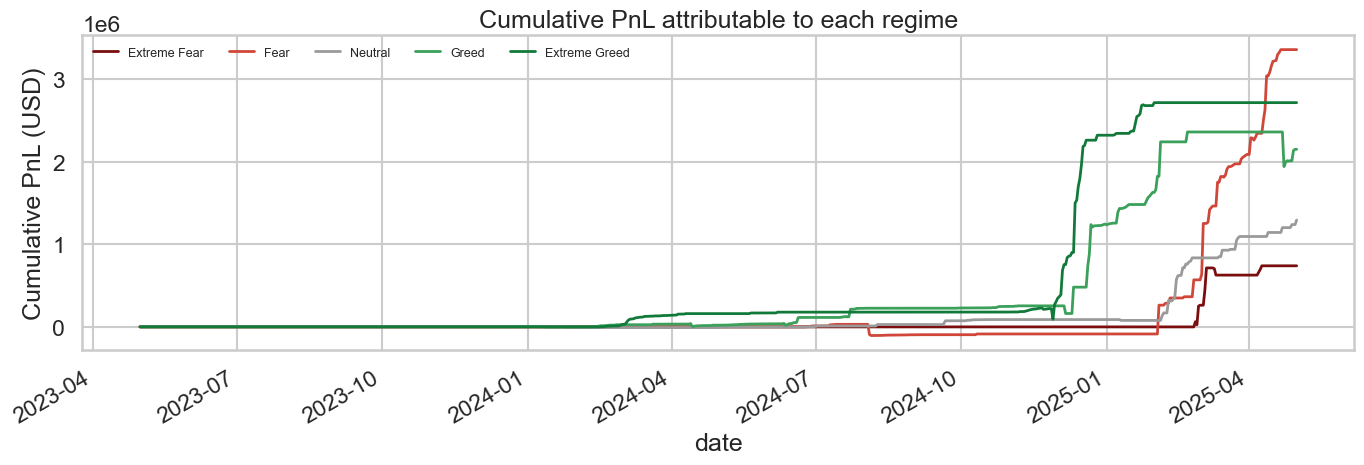

In [6]:
daily = df.dropna(subset=['regime']).groupby(['date','regime'], observed=True)['closed_pnl'].sum().unstack(fill_value=0)
daily = daily.reindex(columns=REGIME_ORDER, fill_value=0)
cumulative = daily.cumsum()
fig, ax = plt.subplots(figsize=(14, 5))
for r in REGIME_ORDER:
    cumulative[r].plot(ax=ax, color=PALETTE[r], label=r, linewidth=2)
ax.set_title('Cumulative PnL attributable to each regime')
ax.set_ylabel('Cumulative PnL (USD)')
ax.legend(loc='upper left', ncol=5, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cumulative_pnl_by_regime.png', dpi=140)
plt.show()
plt.close('all')
